In [2]:
#PART 1: INITIAL VEHICLE ANALYSIS

In [3]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')

In [4]:
#### Load in the data in csv

 # importing the national household travel survey
nhts_data=pd.read_csv('NHTS.csv')
nhts_data.columns
# Perform the previously learned techniques to visualize the head, tail, columns, and print the data 

Index(['household_id', 'census_division', 'census_region', 'driver_count',
       'household_income', 'household_size', 'household_workers', 'home_type',
       'household_location', 'number_adults_household',
       'vehicles_per_household', 'travel_date', 'travel_day', 'urban',
       'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial',
       'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year'],
      dtype='object')

In [5]:
nhts_data.describe()

,household_id,driver_count,household_size,household_workers,number_adults_household,vehicles_per_household,travel_date,vehicle_age,vehicle_year
count,1.468400e+04,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,9.000113e+09,2.014165,2.558090,1.179447,2.061223,2.534323,202211.722623,10.174271,2011.866658
std,5.936829e+04,0.814926,1.333751,0.984043,0.812286,1.436046,20.578951,7.959353,8.009252
min,9.000013e+09,0.000000,1.000000,0.000000,1.000000,1.000000,202201.000000,1.000000,1982.000000
25%,9.000057e+09,2.000000,2.000000,0.000000,2.000000,2.000000,202204.000000,4.000000,2007.000000
50%,9.000107e+09,2.000000,2.000000,1.000000,2.000000,2.000000,202208.000000,8.000000,2014.000000
75%,9.000166e+09,2.000000,3.000000,2.000000,2.000000,3.000000,202211.000000,15.000000,2018.000000
max,9.000218e+09,7.000000,10.000000,6.000000,8.000000,17.000000,202301.000000,40.000000,2023.000000


In [6]:
nhts_data['make'].value_counts()

make
Toyota                                        1974
Ford                                          1921
Chevrolet                                     1571
Honda                                         1507
Nissan/Datsun                                  702
Subaru                                         601
Dodge                                          582
Jeep                                           554
Hyundai                                        516
Other make                                     500
Suppressed for confidential reason             457
GMC                                            447
KIA                                            376
Volkswagen                                     315
Mazda                                          292
Lexus                                          291
BMV                                            290
Buick/Opel                                     239
Mercedes-Benz                                  228
Chrysler                  

In [7]:
print(nhts_data.isnull().sum())

household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64


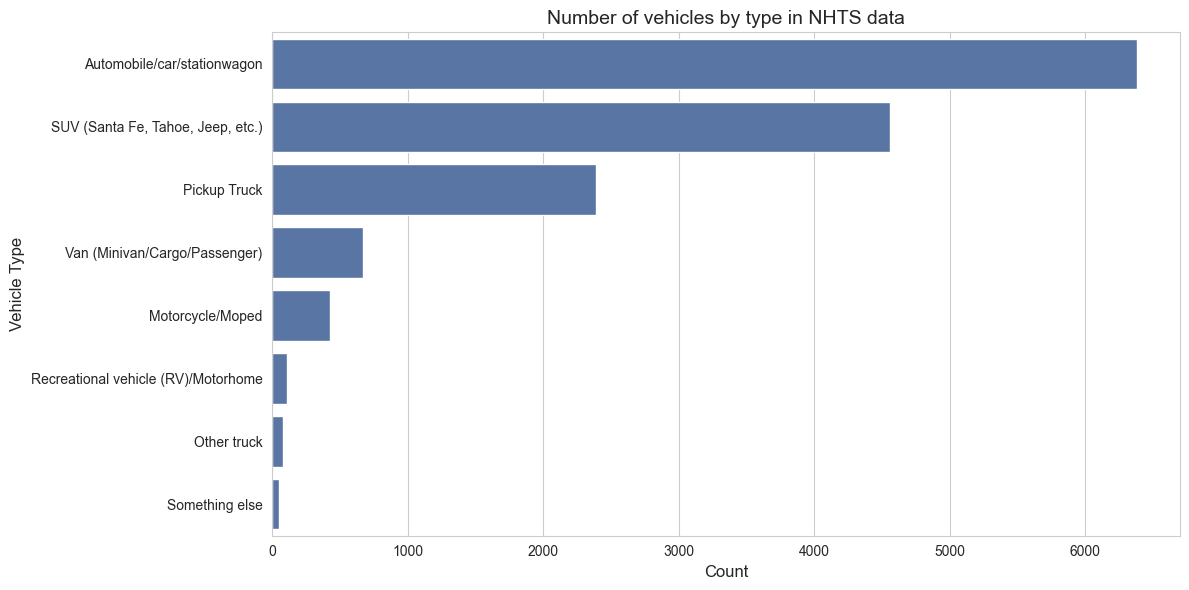

In [8]:
## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize=(12,6))

## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal
sns.countplot(data=nhts_data,y='vehicle_type',order=nhts_data['vehicle_type'].value_counts().index)

## Step 3: add labels and title
plt.xlabel('Count',fontsize=12)
plt.ylabel('Vehicle Type',fontsize=12)
plt.title('Number of vehicles by type in NHTS data',fontsize=14)

## Step 4: show the plot
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

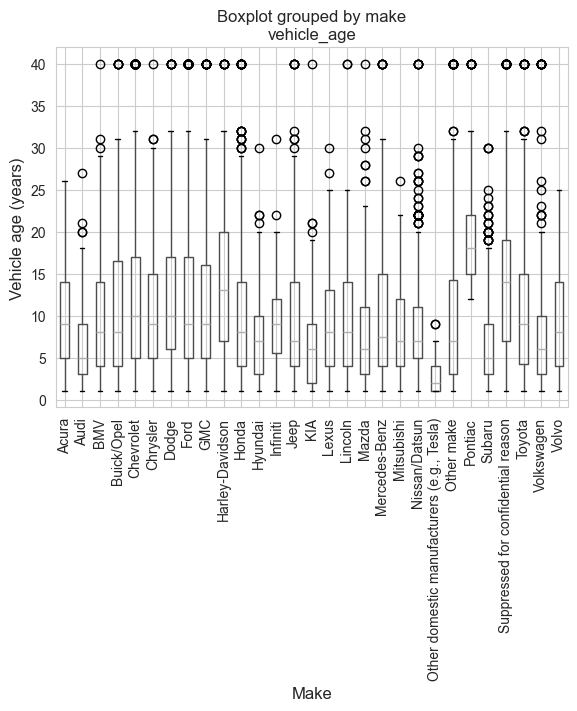

In [9]:
## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize=(12,6))

## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot=nhts_data.boxplot(column='vehicle_age',by='make')
plt.xticks(rotation=90)
plt.xlabel("Make",fontsize=12)
plt.ylabel('Vehicle age (years)',fontsize=12)
## Step 3: tell python to show the plot
plt.show()

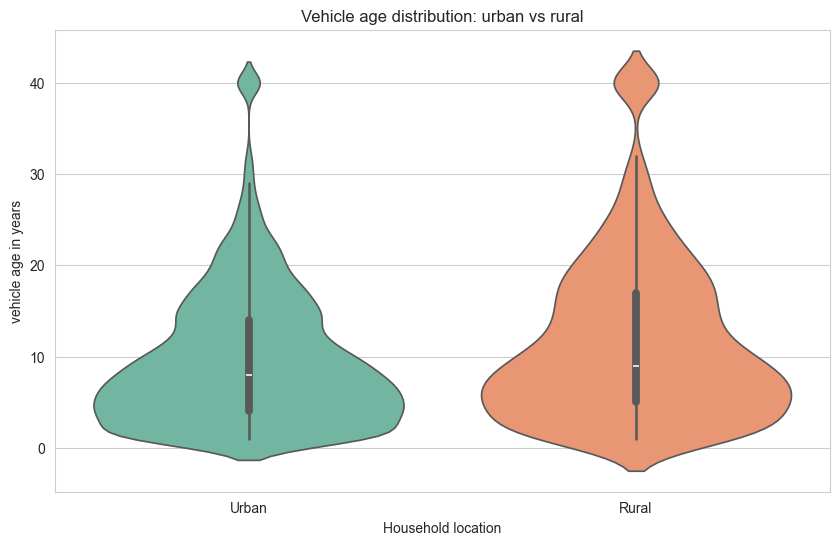

In [10]:
## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize=(10,6))

## Step 2: use sns.violinplot with x='household_location' and y='vehicle_age'
# hint: you can add the argument inner='box' to show a mini boxplot inside the violin!
# use hue='household_location' and legend=False for coloring
sns.violinplot(data=nhts_data,x='household_location',y='vehicle_age',
               hue='household_location',inner='box',palette='Set2',legend=False)

## Step 3: add labels and title
plt.xlabel('Household location')
plt.ylabel("vehicle age in years")
plt.title("Vehicle age distribution: urban vs rural")

## Step 4: show the plot
plt.show()

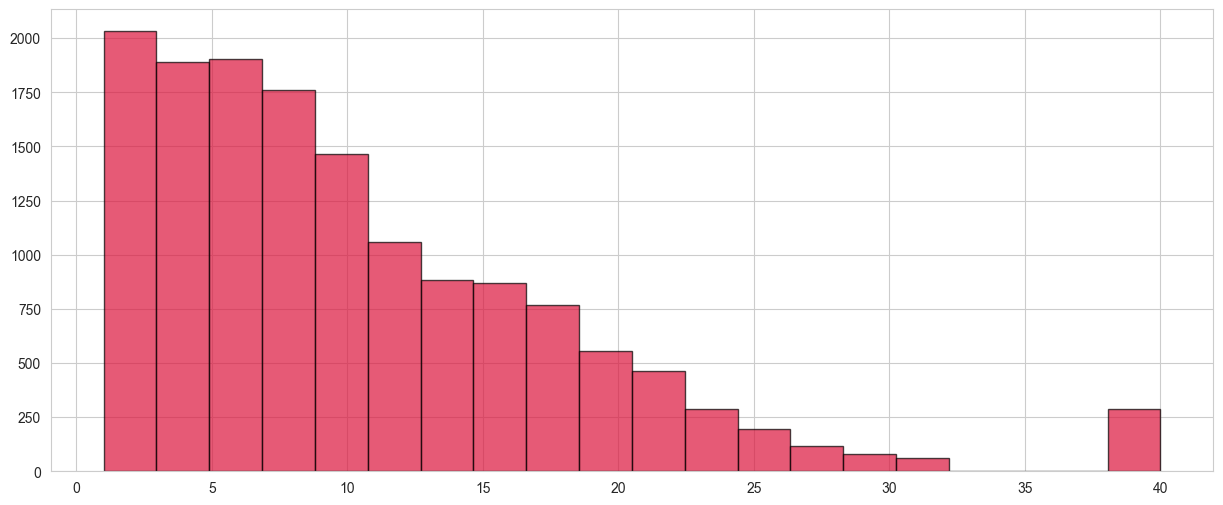

In [11]:
##Tell Python you are plotting a figure and how big you want the figure to be
plt.figure(figsize=(15,6))

## Tell Python what type of plot you want. Here, .hist() creates a histogram
plt.hist(nhts_data['vehicle_age'],bins=20,edgecolor='black',alpha=0.7,color='crimson')

# Then let's label. You'll notice you can change the fontsize of all your labels!
plt.show()

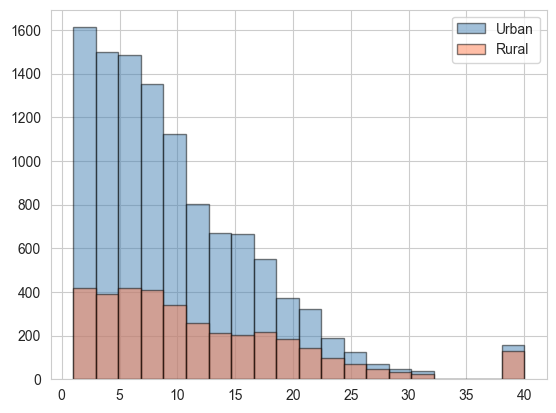

In [12]:
urban_ages=nhts_data[nhts_data['household_location']=='Urban']['vehicle_age']
plt.hist(urban_ages,bins=20,edgecolor='black',alpha=0.5,color='steelblue',label='Urban')

## Step 3: filter and plot Rural vehicle ages on the same figure
rural_ages=nhts_data[nhts_data['household_location']=='Rural']['vehicle_age']
plt.hist(rural_ages,bins=20,edgecolor='black',alpha=0.5,color='coral',label='Rural')


## Step 4: add labels, title, and legend
plt.legend()
plt.show()

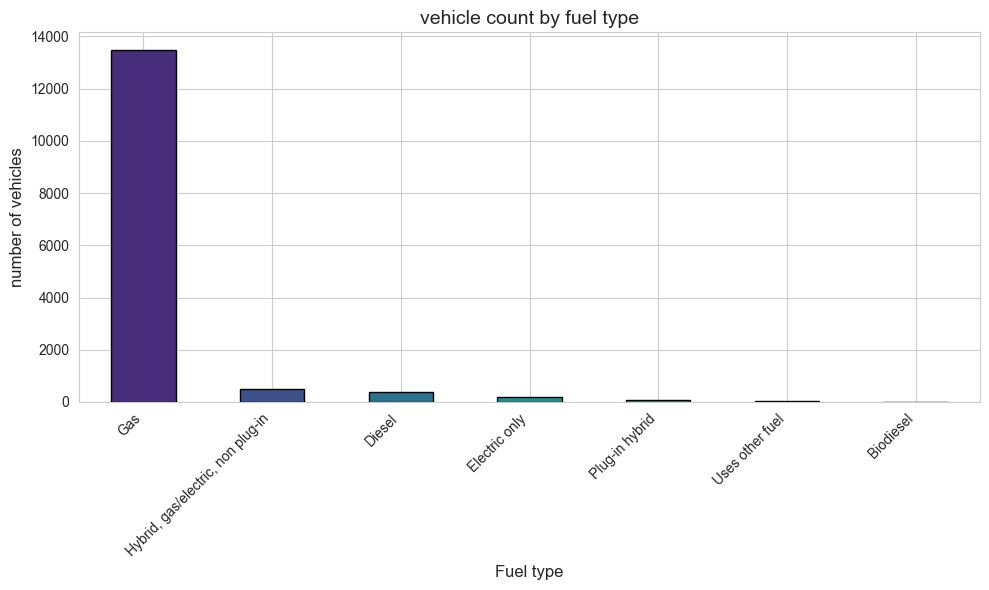

In [13]:
fuel_counts=nhts_data['fuel_type'].value_counts().dropna()

## Step 2: create the bar plot
plt.figure(figsize=(10,6))
fuel_counts.plot(kind='bar',color=sns.color_palette('viridis',len(fuel_counts)),edgecolor='black')

## Step 3: add labels and customization
plt.xlabel('Fuel type', fontsize=12)
plt.ylabel('number of vehicles', fontsize=12)
plt.title('vehicle count by fuel type', fontsize=14)
plt.xticks(rotation=45,ha='right')

## Step 4: show the plot
plt.tight_layout()
plt.show()

<Figure size 4000x2000 with 0 Axes>

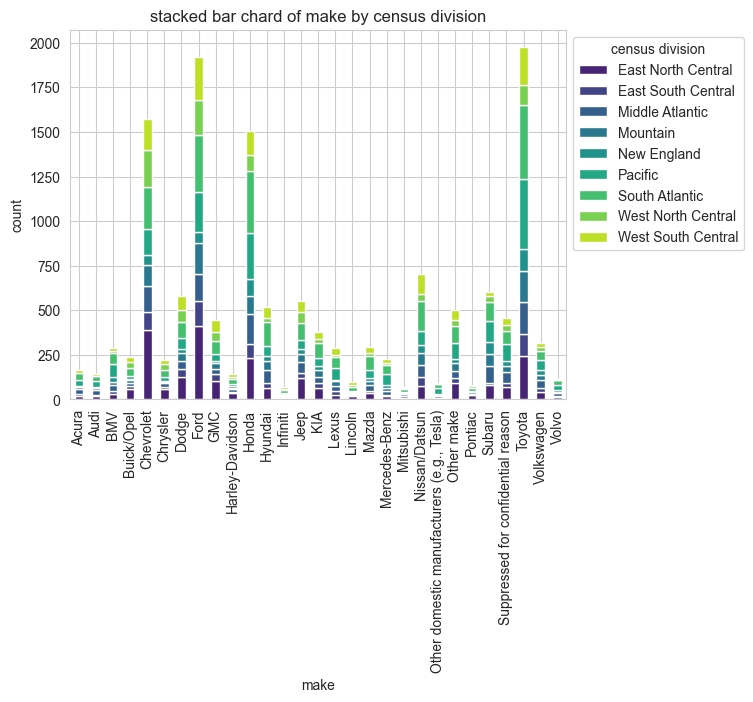

In [14]:
nhts_data=nhts_data.dropna(subset=['make'])

data_grouped=nhts_data.groupby(['make','census_division']).size().unstack(fill_value=0)
plt.figure(figsize=(40,20))
data_grouped.plot(kind='bar',stacked=True,color=sns.color_palette('viridis',len(data_grouped.columns)))
plt.xlabel('make')
plt.ylabel('count')
plt.title('stacked bar chard of make by census division')
plt.xticks(rotation=90)

plt.legend(title='census division',bbox_to_anchor=(1,1),loc='upper left')


plt.show()

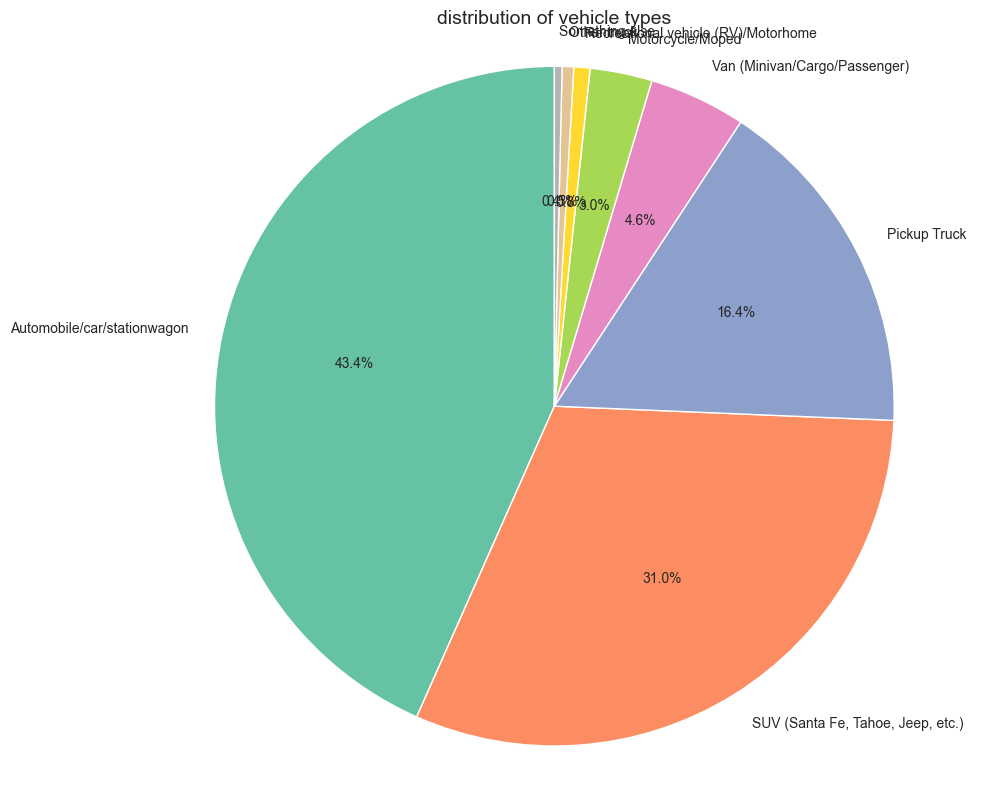

In [15]:
type_counts=nhts_data['vehicle_type'].value_counts()

## Step 2: create the pie chart
# hint: use plt.pie() with arguments: labels=..., autopct='%1.1f%%', startangle=90
# autopct adds percentage labels to each slice
plt.figure(figsize=(10,8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette('Set2',len(type_counts)), 
        textprops={'fontsize': 10})

## Step 3: add title and make it look nice
# hint: plt.axis('equal') ensures the pie is a circle, not an ellipse
plt.axis('equal')
plt.title('distribution of vehicle types',fontsize=14)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Heatmap of Vehicle and Driver Attributes')

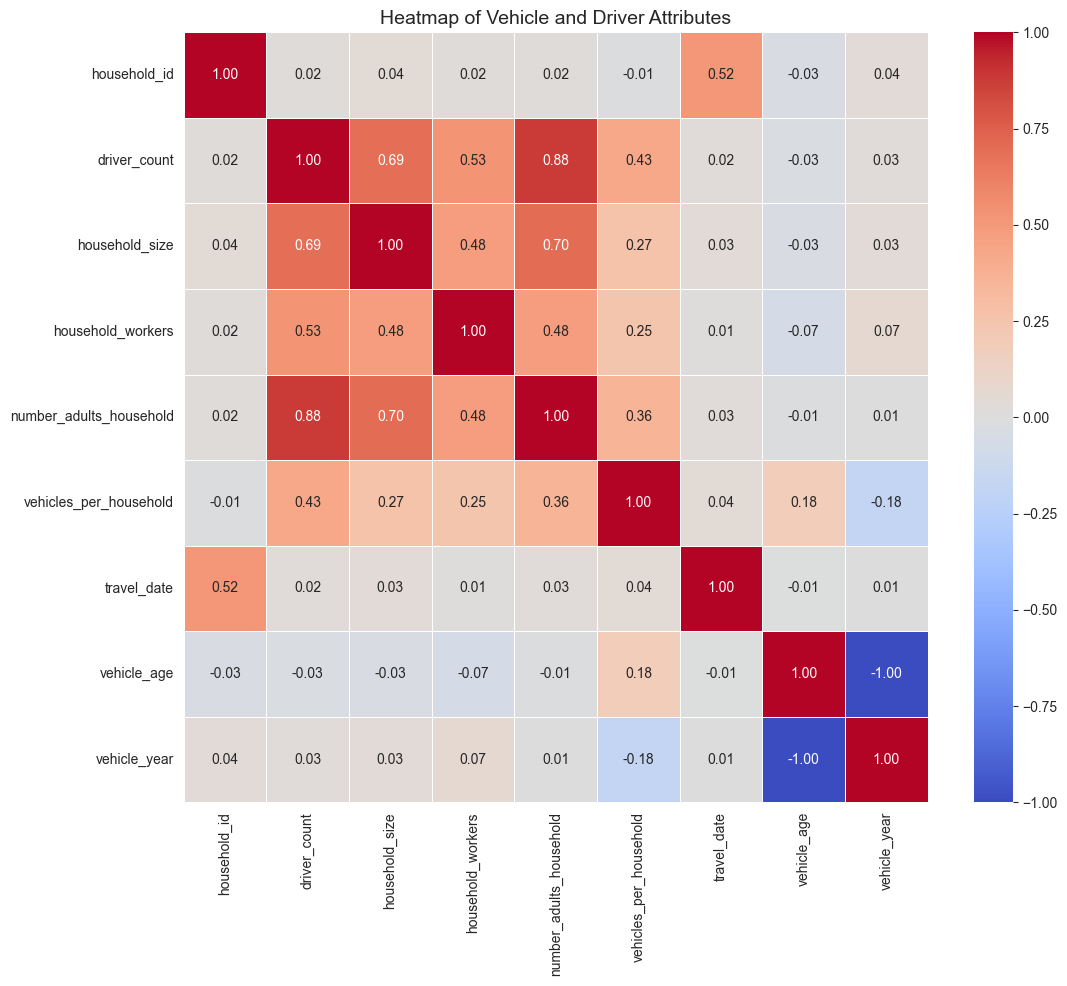

In [16]:
numeric_data=nhts_data.select_dtypes(include=[np.number])

## Step 2: calculate the correlation matrix
# hint: use .corr()
corr_matrix = numeric_data.corr()

## Step 3: create the heatmap
# hint: use sns.heatmap() with arguments: annot=True (show numbers), cmap='coolwarm', fmt='.2f'
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5,vmin=-1,vmax=1)
plt.title("Heatmap of Vehicle and Driver Attributes", fontsize = 14)

In [36]:
#PART 2: BASIC VEHICLE TRAJECTORY COMPARISON

In [18]:
# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM.csv')

# Print the dataset and show its attributes
ngsim_data.head()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.09730,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.00580,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.28600,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-0.88392,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,0.85344,1.780000e-13,1


In [19]:
### Understanding the Data Structure
print("Columns in dataset:", ngsim_data.columns)
print("Dataset info:")
print(ngsim_data.info())

Columns in dataset: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  8166 non-null   float64
 1   leader_position(m)    8166 non-null   float64
 2   follower_position(m)  8166 non-null   float64
 3   leader_speed(m/s)     8166 non-null   float64
 4   follower_speed(m/s)   8166 non-null   float64
 5   leader_acc(m/s^2)     8166 non-null   float64
 6   follower_acc(m/s^2)   8166 non-null   float64
 7   trajectory_number     8166 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 510.5 KB
None


In [22]:
# Get descriptive statistics for the full dataset
# This gives us the mean, std, min, max, and quartiles for each column
ngsim_data.describe()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
count,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000
mean,27.929611,266.263343,246.576350,8.745533,8.776852,-0.059325,-0.035836,8.176708
std,19.131202,135.110878,134.904708,3.695903,3.784383,1.666269,1.765766,4.811499
min,0.100000,8.227800,0.000000,0.000000,0.000000,-15.240000,-15.240000,1.000000
25%,12.800000,161.337500,141.870000,6.096000,6.096000,-0.365760,-0.365760,4.000000
50%,25.600000,254.180000,237.925000,9.121150,9.128800,0.000000,0.000000,8.000000
75%,38.300000,365.700000,344.990000,12.064000,12.133250,0.335280,0.365760,13.000000
max,84.100000,651.500000,619.050000,17.221000,17.898000,8.046700,15.240000,16.000000


In [23]:
# How many unique trajectory pairs (vehicle pairs) do we have?
print(f'Number of unique trajectories = {ngsim_data['trajectory_number'].nunique()}')

# How many time steps does each trajectory have?
# hint: use .groupby('trajectory_number').size() to count rows per trajectory
print('Timesteps per trajectory: ')
print(ngsim_data.groupby('trajectory_number').size())


Number of unique trajectories = 16
Timesteps per trajectory: 
trajectory_number
1     841
2     398
3     483
4     826
5     401
6     438
7     506
8     394
9     401
10    432
11    447
12    419
13    802
14    448
15    398
16    532
dtype: int64


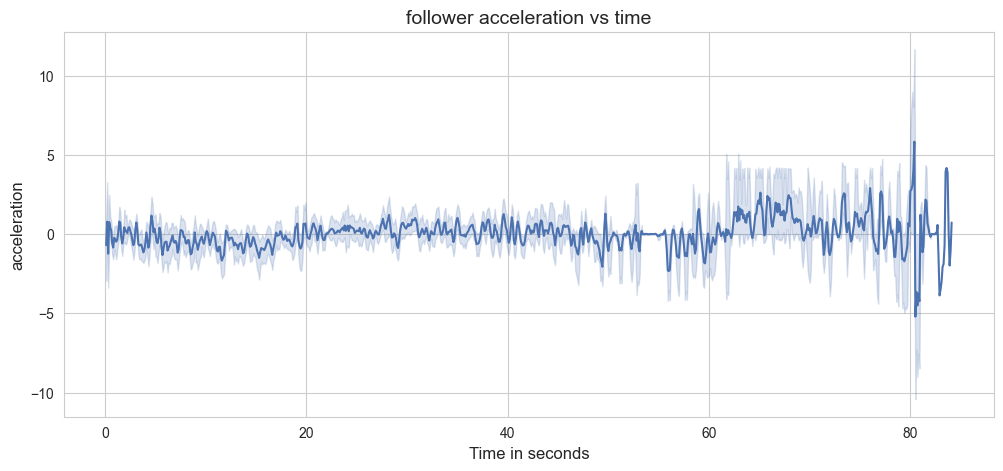

In [24]:
### Plotting Acceleration vs Time

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. 
# Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize=(12,5))
# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x=ngsim_data['Time'],y=ngsim_data['follower_acc(m/s^2)'])
# Step 3: add customizations
plt.xlabel('Time in seconds', fontsize=12)
plt.ylabel('acceleration', fontsize=12)
plt.title('follower acceleration vs time', fontsize=14)
plt.show()

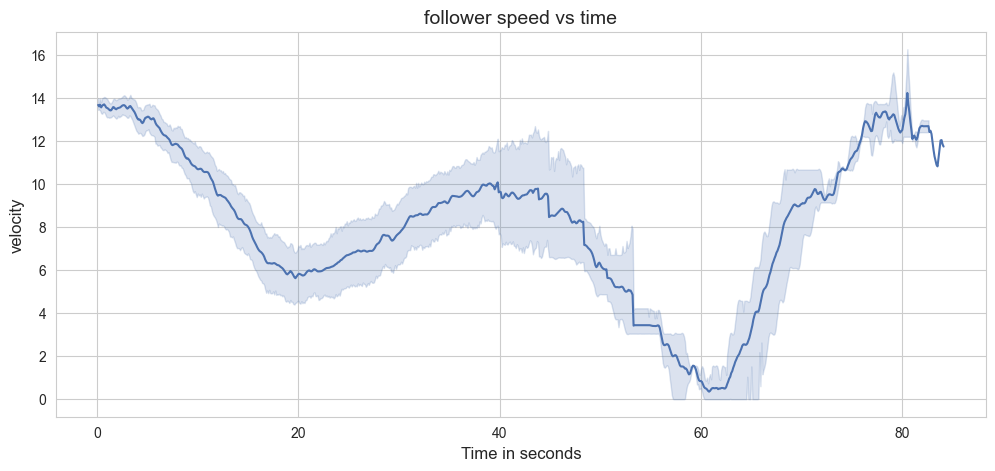

In [25]:
### Plotting Speed vs Time

# replicate the above steps, but now visualize the follower_speed(m/s) data with time 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize=(12,5))
# Step 2: use sns.lineplot to create a time series plot of Time
sns.lineplot(x=ngsim_data['Time'],y=ngsim_data['follower_speed(m/s)'])
# Step 3: add customizations
plt.xlabel('Time in seconds', fontsize=12)
plt.ylabel('velocity', fontsize=12)
plt.title('follower speed vs time', fontsize=14)
plt.show()

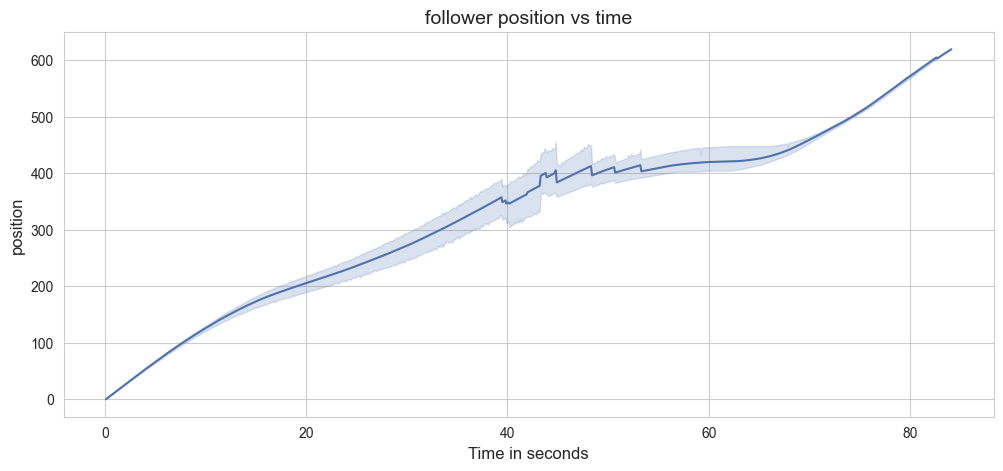

In [26]:
### Plotting Position vs Time

# replicate the above steps, but now visualize the follower_position(m) data with time 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize=(12,5))
# Step 2: use sns.lineplot to create a time series plot
sns.lineplot(x=ngsim_data['Time'],y=ngsim_data['follower_position(m)'])
# Step 3: add customizations
plt.xlabel('Time in seconds', fontsize=12)
plt.ylabel('position', fontsize=12)
plt.title('follower position vs time', fontsize=14)
plt.show()

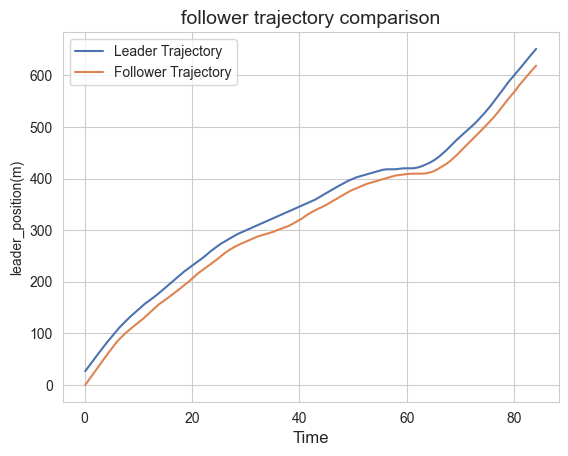

In [27]:
# Select a trajectory number
trajectory_number = 1 # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number']==trajectory_number]

# Plot the position of both vehicles over time
# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time 
    # another lineplot for follower position vs time
sns.lineplot(x=data_subset['Time'], y=data_subset['leader_position(m)'], label=['Leader Trajectory'])
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_position(m)'], label=['Follower Trajectory'])
plt.xlabel('Time', fontsize=12)
plt.title('follower trajectory comparison', fontsize=14)
plt.show()

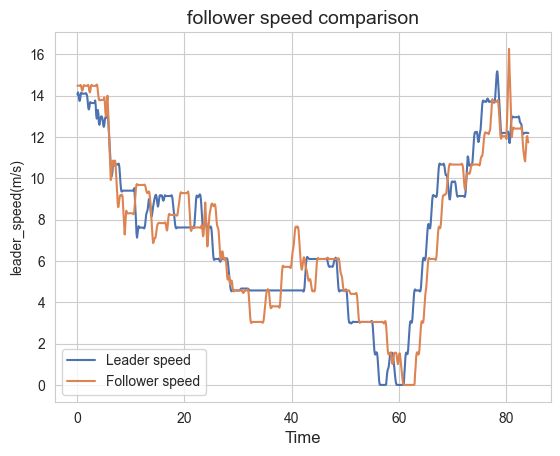

In [28]:
# Now replicate the same but visualizing speed
sns.lineplot(x=data_subset['Time'], y=data_subset['leader_speed(m/s)'], label=['Leader speed'])
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_speed(m/s)'], label=['Follower speed'])
plt.xlabel('Time', fontsize=12)
plt.title('follower speed comparison', fontsize=14)
plt.show()

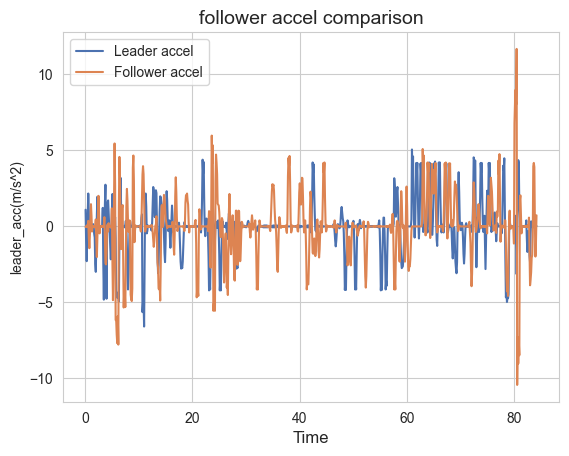

In [29]:
# Now replicating the same but visualizing accelerationsns.lineplot(x=data_subset['Time'], y=data_subset['leader_speed(m/s)'], label=['Leader speed'])
sns.lineplot(x=data_subset['Time'], y=data_subset['leader_acc(m/s^2)'], label=['Leader accel'])
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_acc(m/s^2)'], label=['Follower accel'])
plt.xlabel('Time', fontsize=12)
plt.title('follower accel comparison', fontsize=14)
plt.show()

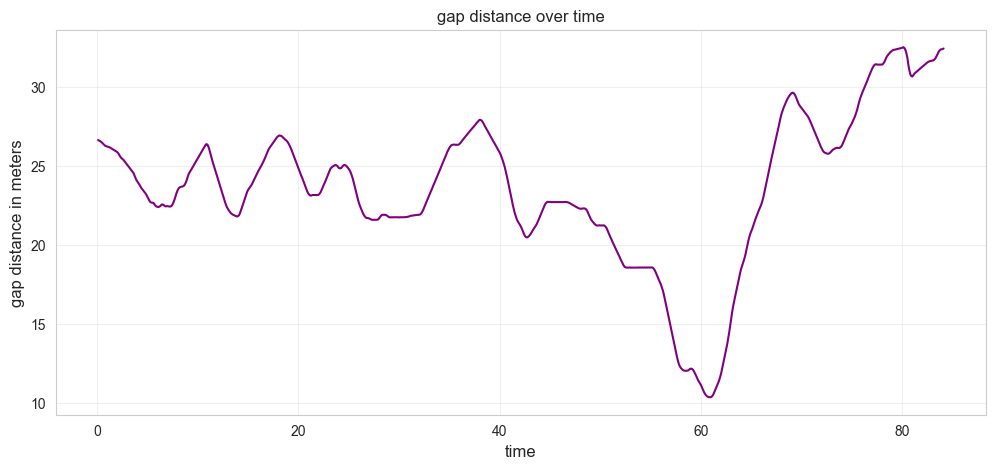

In [30]:
# Now try to plot the gap distance between two vehicle pairs. Gap = position of leader - position of follower
# Plot the gap distance over time 
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

plt.figure(figsize=(12,5))
plt.plot(data_subset['Time'], gap_distance, color='purple', linewidth=1.5)
plt.xlabel('time',fontsize=12)
plt.ylabel('gap distance in meters',fontsize=12)
plt.title('gap distance over time', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

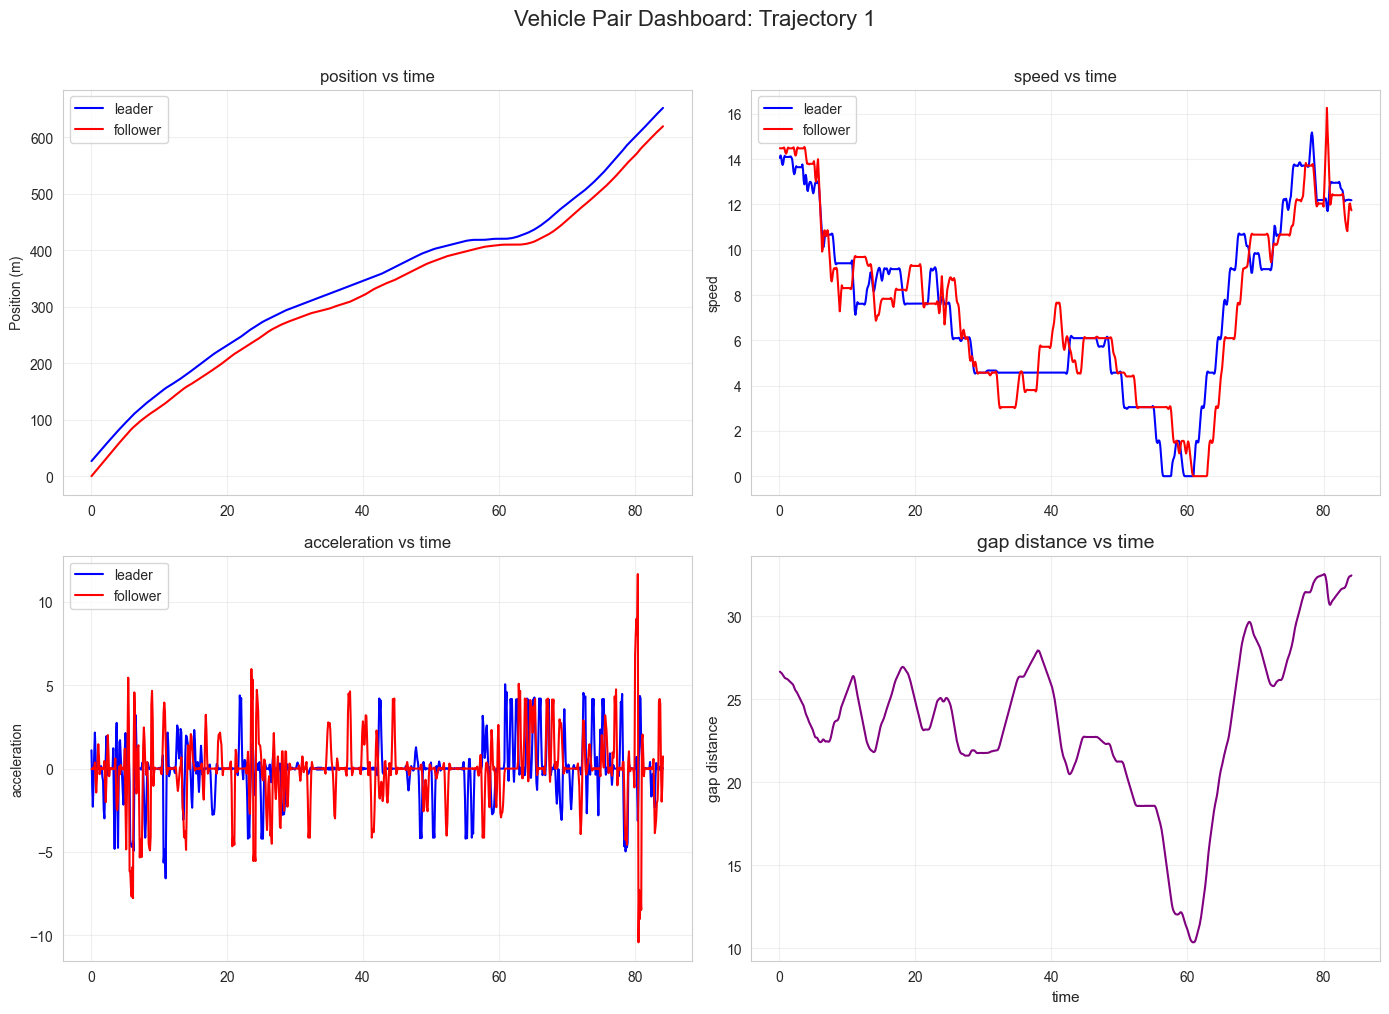

In [31]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Step 1: Select a trajectory number and create the subset
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number']==trajectory_number]
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time=data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
# hint: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# Step 3: Top-left (axes[0,0]): Position vs Time for both leader and follower
axes[0,0].plot(time, data_subset['leader_position(m)'].values, 'b-',label='leader',linewidth=1.5)
axes[0,0].plot(time, data_subset['follower_position(m)'].values, 'r-',label='follower',linewidth=1.5)
axes[0,0].set_ylabel('Position (m)', fontsize=10)
axes[0,0].set_title('position vs time', fontsize=12)
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True,alpha=0.3)

# Step 4: Top-right (axes[0,1]): Speed vs Time for both leader and follower
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, 'b-',label='leader',linewidth=1.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, 'r-',label='follower',linewidth=1.5)
axes[0,1].set_ylabel('speed', fontsize=10)
axes[0,1].set_title('speed vs time', fontsize=12)
axes[0,1].legend(fontsize=10)
axes[0,1].grid(True,alpha=0.3)

# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, 'b-',label='leader',linewidth=1.5)
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, 'r-',label='follower',linewidth=1.5)
axes[1,0].set_ylabel('acceleration', fontsize=10)
axes[1,0].set_title('acceleration vs time', fontsize=12)
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True,alpha=0.3)

# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time
axes[1,1].plot(time, gap,'purple',linewidth=1.5)
axes[1,1].set_xlabel('time',fontsize=11)
axes[1,1].set_ylabel('gap distance',fontsize=11)
axes[1,1].set_title('gap distance vs time',fontsize=14)
axes[1,1].grid(True,alpha=0.3)

# Step 7: Add title for the whole figure and adjust layout
plt.suptitle(f'Vehicle Pair Dashboard: Trajectory {trajectory_number}',fontsize=16,y=1.01)
plt.tight_layout()
plt.show()

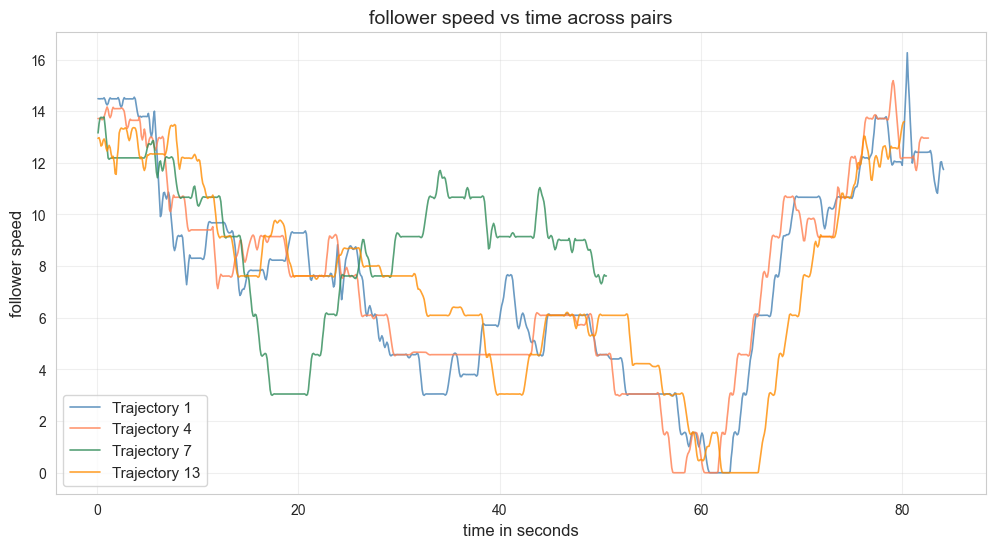

In [32]:
# Compare the follower speed profile for 4 different trajectory pairs on the same plot
# This shows us the variation in driving behavior across different vehicle pairs

# hint: loop through trajectory_numbers = [1, 4, 7, 13]
# for each one, filter the data and plot the follower speed vs time

trajectory_numbers = [1, 4, 7, 13]
colors= ['steelblue','coral','seagreen','darkorange']

plt.figure(figsize=(12,6))

for traj, color, in zip(trajectory_numbers, colors):
    subset = ngsim_data[ngsim_data['trajectory_number']==traj]
    plt.plot(subset['Time'].values, subset['follower_speed(m/s)'].values,color=color,linewidth=1.2,label=f'Trajectory {traj}',alpha=0.8)

plt.xlabel('time in seconds',fontsize=12)
plt.ylabel('follower speed',fontsize=12)
plt.title('follower speed vs time across pairs',fontsize=14)
plt.legend(fontsize=11)
plt.grid(True,alpha=0.3)
plt.show()

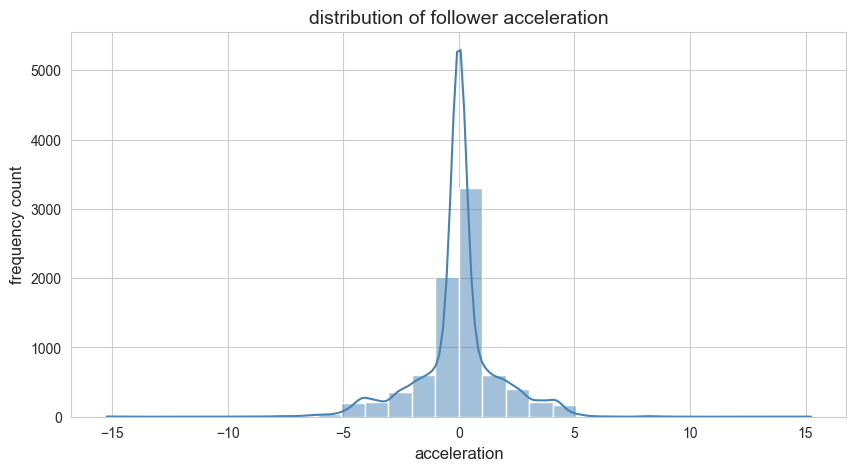

In [33]:
## Here you are asked to show a histogram of the acceleration. 
## Specifically, we want to see how acceleration values are distributed for the following cars
# here try to use the sns.histplot graph 
plt.figure(figsize=(10,5))
sns.histplot(ngsim_data['follower_acc(m/s^2)'],bins=30, kde=True,color='steelblue')
plt.xlabel('acceleration',fontsize=12)
plt.ylabel('frequency count',fontsize=12)
plt.title('distribution of follower acceleration',fontsize=14)
plt.show()

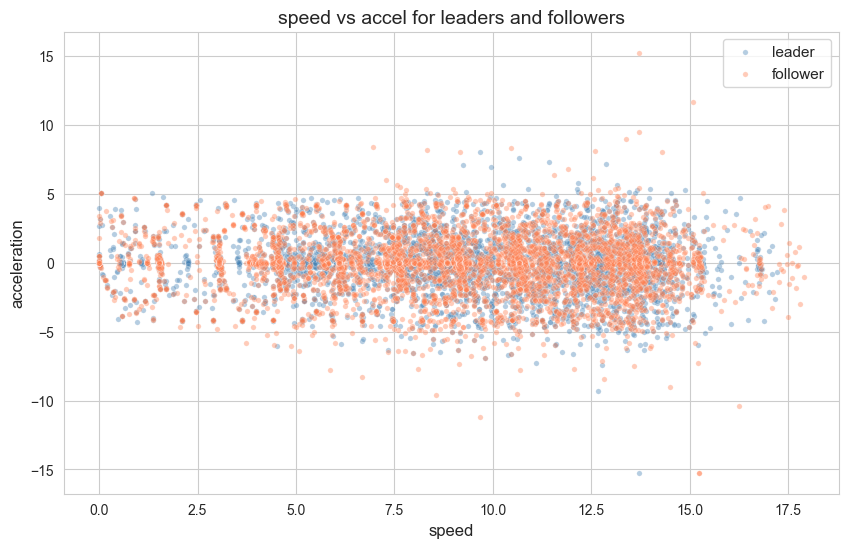

In [34]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=ngsim_data['leader_speed(m/s)'],y=ngsim_data['leader_acc(m/s^2)'],label='leader',alpha=0.4,color='steelblue',s=15)
sns.scatterplot(x=ngsim_data['follower_speed(m/s)'],y=ngsim_data['follower_acc(m/s^2)'],label='follower',alpha=0.4,color='coral',s=15)
plt.xlabel('speed',fontsize=12)
plt.ylabel('acceleration',fontsize=12)
plt.title('speed vs accel for leaders and followers',fontsize=14)
plt.legend(fontsize=11)
plt.show()

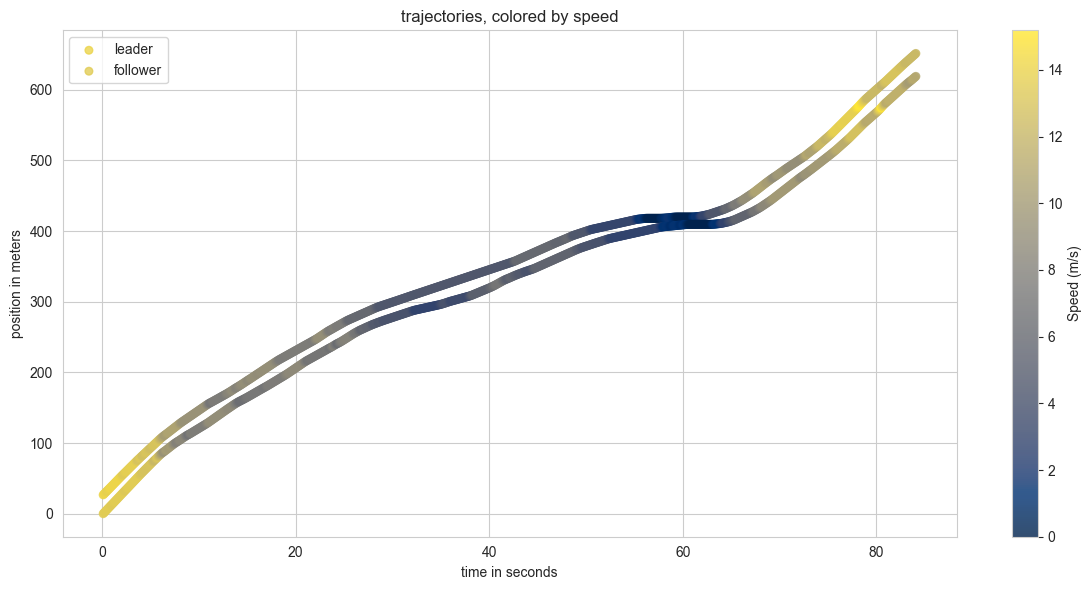

In [35]:
# Step 1: Select a trajectory number
trajectory_number=1  # Example trajectory

# Step 2: Select the data based on the subset
data_subset=ngsim_data[ngsim_data['trajectory_number']==trajectory_number]

# Step 3: Create a single figure
plt.figure(figsize=(12,6))

# Step 4: Scatter plot for leader – color by leader speed
sc1 = plt.scatter(data_subset['Time'],
                  data_subset['leader_position(m)'],
                  c=data_subset['leader_speed(m/s)'],
                  cmap='cividis',
                  s=30,
                  alpha=0.8,
                  label='leader')

# Step 5: Scatter plot for follower – color by follower speed
sc2 = plt.scatter(data_subset['Time'],
                  data_subset['follower_position(m)'],
                  c=data_subset['follower_speed(m/s)'],
                  cmap='cividis',
                  s=30,
                  alpha=0.8,
                  label='follower')

# Add a colorbar (the same color scale works for both)
cbar = plt.colorbar(sc1)
cbar.set_label('Speed (m/s)')

# Labels and title
plt.xlabel('time in seconds')
plt.ylabel('position in meters')
plt.title('trajectories, colored by speed')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
#PART 3: ADVANCED VEHICLE TRAJECTORY SIMULATION

In [38]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    # s_star = s0 + v * T + (v * delta_v) / (2 * sqrt(a * b))
    s_star = s0+v*T+(v*delta_v)/(2*np.sqrt(a*b))
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0) # always positive
    
    # Step 2: Calculate the acceleration using the IDM equation
    # acceleration = a * [1 - (v/v0)^delta - (s_star/s)^2]
    
    acceleration = a*(1-(v/v0)**delta-(s_star/s)**2)
    
    return acceleration

In [39]:
# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print(f"IDM acceleration: {test_acc:.4f} m/s^2")

IDM acceleration: -2.9348 m/s^2


In [40]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number']==trajectory_number].reset_index(drop=True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1

In [41]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]  #this makes the starting value [0] same as the follower vehicle speed


print(sim_position)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [42]:
for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1) #prevent negative
    delta_v = sim_speed[i]-leader_speed[i]              

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    print(sim_acc[i])

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1]=max(sim_speed[i] + sim_acc[i]*dt,0) #equation of motion
    sim_position[i+1] = sim_position[i]+sim_speed[i]*dt

print("Simulation complete!")

-0.02562543796815897
0.020369633022278344
-0.02682388177534667
-0.13121608520327244
-0.16990023485634642
-0.12518843717800743
-0.024838170302323714
0.017795031928132587
-0.007891110629488107
-0.009892509654448545
-0.011779894007890812
-0.014955309418271723
-0.01522255753152657
-0.018122807833802823
-0.01693198040590782
-0.011731085594215984
-0.01206296568318399
-0.03507528270886873
-0.06927635325181891
-0.18419043053790263
-0.32712093640003925
-0.37387892253649513
-0.3201888378176393
-0.2092147755339756
-0.1598768986098622
-0.17415453742895992
-0.16974136694959896
-0.1640105912038965
-0.15850723514662501
-0.1518586504401418
-0.14831571345647088
-0.14342317670503402
-0.13880674375106017
-0.0763409295178813
-0.19359073416230133
-0.43691320635062336
-0.5000888502899246
-0.39593448827837907
-0.23432282096592416
-0.3129077810493258
-0.5596539057408826
-0.5712518376780799
-0.45254746309973504
-0.3387259951006303
-0.2830325974829183
-0.2707362428230685
-0.28137525438212174
-0.3429547603797123

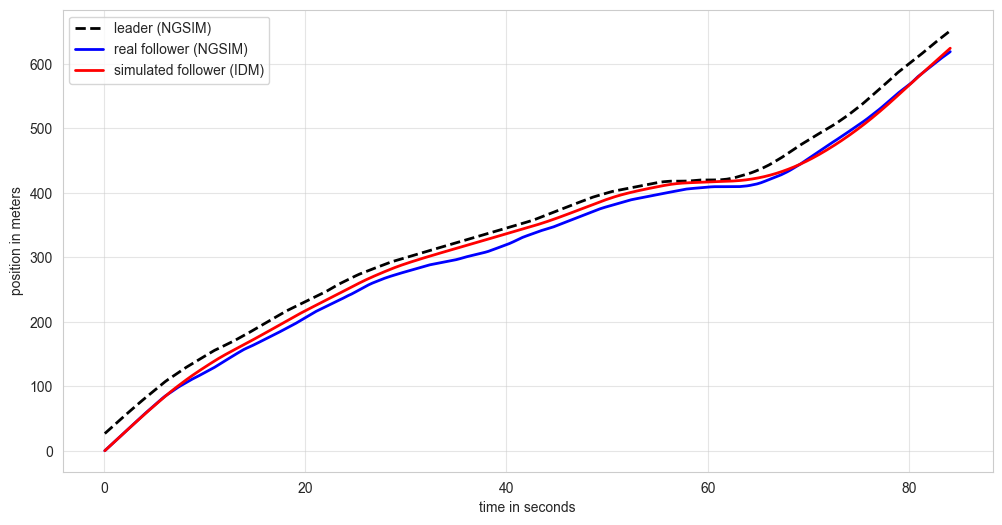

In [43]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize=(12,6))
plt.plot(time_data, leader_position, 'k--', linewidth=2, label = 'leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, 'b-', linewidth = 2, label = 'real follower (NGSIM)')
plt.plot(time_data, sim_position, 'r-', linewidth = 2, label = 'simulated follower (IDM)')
plt.xlabel('time in seconds')
plt.ylabel('position in meters')
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()